# 📦 Senti-Recommend: Data Collection Pipeline
### Phase 1 — Web Scraping & Data Acquisition

---

**Project:** Senti-Recommend: A Hybrid AI Tool Discovery Engine  
**Module:** Data Collection & Preprocessing  
**Author:** [Your Name]  
**Programme:** PGD Data Science  

---

## 📌 Purpose of This Notebook

This notebook documents **Phase 1** of the Senti-Recommend project pipeline: collecting raw data about AI tools.  
It covers:

1. Understanding the data sources and why they were chosen
2. Setting up the scraping environment
3. Scraping AI tool **metadata** (name, rating, category, pricing, installs)
4. Scraping **user reviews** (text, score, date)
5. Validating and exporting the collected dataset

> **⚠️ Ethical Note:** All scraping in this project respects website `robots.txt` files, uses rate-limiting (time delays), and collects only publicly visible data. This is in line with standard academic data collection practice.

---

## 🗂️ Final Dataset Overview

After running this pipeline we produce two files that feed directly into later project phases:

| File | Contents | Rows | Columns |
|---|---|---|---|
| `ai_tools_metadata.csv` | App info, ratings, pricing, installs | 482 | 30 |
| `ai_tools_reviews.csv` | Individual user reviews with scores | Variable | 8+ |


---
## 🔧 Section 1 — Library Installation & Imports

### Why these libraries?

| Library | Role in this project |
|---|---|
| `google-play-scraper` | Primary data source — scrapes Google Play Store app metadata and reviews without requiring API keys |
| `requests` | Makes HTTP requests to web pages (backup scraping layer) |
| `BeautifulSoup4` | Parses raw HTML to extract structured data from web pages |
| `pandas` | Stores, cleans and exports tabular data |
| `tqdm` | Displays a progress bar during long scraping loops |
| `time` / `random` | Adds delays between requests to be ethical and avoid IP bans |
| `json` | Handles structured API-style responses |
| `re` | Regular expressions for cleaning text |
| `logging` | Captures errors during scraping to a log file instead of crashing |


In [1]:
# ── Install required libraries ──────────────────────────────────────────────
# Run this cell once. Restart the kernel after installation completes.

!pip install google-play-scraper requests beautifulsoup4 pandas tqdm

Defaulting to user installation because normal site-packages is not writeable
  Using cached google_play_scraper-1.2.7-py3-none-any.whl.metadata (50 kB)
Using cached google_play_scraper-1.2.7-py3-none-any.whl (28 kB)

   ---------------------------------------- 0/5 [soupsieve]
   -------- ------------------------------- 1/5 [google-play-scraper]
   -------- ------------------------------- 1/5 [google-play-scraper]
   ---------------- ----------------------- 2/5 [colorama]
   ---------------- ----------------------- 2/5 [colorama]
   ------------------------ --------------- 3/5 [tqdm]
   ------------------------ --------------- 3/5 [tqdm]
   ------------------------ --------------- 3/5 [tqdm]
   ------------------------ --------------- 3/5 [tqdm]
   -------------------------------- ------- 4/5 [beautifulsoup4]
   -------------------------------- ------- 4/5 [beautifulsoup4]
   -------------------------------- ------- 4/5 [beautifulsoup4]
   -------------------------------- ------- 4/5 [

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
# ── Core imports ─────────────────────────────────────────────────────────────
import pandas as pd
import json
import time
import random
import re
import logging
from datetime import datetime
from tqdm import tqdm

# Web scraping
import requests
from bs4 import BeautifulSoup

# Google Play Scraper — our primary tool
from google_play_scraper import app, reviews, search, Sort
from google_play_scraper.exceptions import NotFoundError

# ── Logging configuration ─────────────────────────────────────────────────────
# Errors are written to a log file so the notebook does not crash mid-run
logging.basicConfig(
    filename='scraping_errors.log',
    level=logging.ERROR,
    format='%(asctime)s — %(levelname)s — %(message)s'
)

print("✅ All libraries imported successfully.")
print(f"📅 Scraping session started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ All libraries imported successfully.
📅 Scraping session started at: 2026-02-25 21:02:27


---
## 📡 Section 2 — Data Source Selection & Justification

### Why Google Play Store?

Three candidate sources were evaluated:

| Source | Pros | Cons | Selected? |
|---|---|---|---|
| **Google Play Store** | Free, no API key, millions of reviews, structured metadata | Android-centric | ✅ **Primary** |
| G2 / Capterra | B2B-focused, detailed | Requires login/API key, rate-limited | ⚠️ Supplementary |
| ProductHunt | Captures new/trendy tools | Sparse review data | ⚠️ Supplementary |

Google Play was selected as the **primary source** because:
- The `google-play-scraper` library provides stable, structured access
- It contains all 30 metadata fields needed (ratings breakdown, install counts, pricing, version history)
- Review volume is sufficient for meaningful NLP analysis

### Scope Filter — 5 AI Categories

Per the project scope, only these categories are collected:

```
1. Generative Text (chatbots, writing assistants)
2. Image Generation (AI art, photo tools)
3. AI Coding Assistants
4. Productivity Tools (AI organizers, summarizers)
5. Marketing AI (copy generators, SEO tools)
```


In [3]:
# ── Configuration: Search terms for each of the 5 project categories ──────────

CATEGORY_QUERIES = {
    "Generative Text": [
        "AI chatbot assistant",
        "AI writing assistant",
        "ChatGPT app",
        "AI text generator"
    ],
    "Image Generation": [
        "AI image generator",
        "AI art generator",
        "text to image AI"
    ],
    "AI Coding Assistants": [
        "AI code assistant",
        "programming AI helper",
        "code autocomplete AI"
    ],
    "Productivity Tools": [
        "AI productivity app",
        "AI note taking",
        "AI summarizer app",
        "AI task manager"
    ],
    "Marketing AI": [
        "AI marketing tool",
        "AI copywriting",
        "AI social media content"
    ]
}

# How many apps to retrieve per search query
RESULTS_PER_QUERY = 10

# How many reviews to collect per app
REVIEWS_PER_APP = 100

# Delay range (seconds) between requests — ethical scraping
DELAY_MIN = 1.5
DELAY_MAX = 3.5

print("⚙️  Configuration loaded.")
print(f"   Categories    : {len(CATEGORY_QUERIES)}")
print(f"   Total queries : {sum(len(v) for v in CATEGORY_QUERIES.values())}")
print(f"   Results/query : {RESULTS_PER_QUERY}")
print(f"   Reviews/app   : {REVIEWS_PER_APP}")

⚙️  Configuration loaded.
   Categories    : 5
   Total queries : 17
   Results/query : 10
   Reviews/app   : 100


---
## 🔍 Section 3 — Step 1: Discovering App IDs via Search

Before fetching full details, we first **search** Google Play using our keyword queries to build a master list of relevant app IDs. This two-step approach (search → then fetch) is more reliable than scraping directly.

**Output:** A deduplicated list of `(app_id, category)` pairs.


In [4]:
# ── Step 1: Search for app IDs per category ───────────────────────────────────

discovered_apps = []   # Will hold dicts of {app_id, category, query}
seen_app_ids   = set() # Deduplication tracker

print("🔍 Searching Google Play Store for AI tools...\n")

for category, queries in CATEGORY_QUERIES.items():
    print(f"  📂 Category: {category}")
    
    for query in queries:
        try:
            # Search Google Play — returns a list of app summaries
            results = search(
                query,
                lang='en',
                country='us',
                n_hits=RESULTS_PER_QUERY
            )
            
            new_count = 0
            for result in results:
                app_id = result['appId']
                if app_id not in seen_app_ids:
                    seen_app_ids.add(app_id)
                    discovered_apps.append({
                        'app_id'         : app_id,
                        'app_name_preview': result.get('title', 'Unknown'),
                        'project_category': category,
                        'discovery_query' : query
                    })
                    new_count += 1
            
            print(f"     ✓ '{query}' → {new_count} new apps found")
            
        except Exception as e:
            logging.error(f"Search failed for query '{query}': {e}")
            print(f"     ✗ '{query}' → ERROR (logged)")
        
        # Ethical delay between requests
        time.sleep(random.uniform(DELAY_MIN, DELAY_MAX))

print(f"\n✅ Discovery complete. Total unique apps found: {len(discovered_apps)}")

# Preview the discovery list
discovery_df = pd.DataFrame(discovered_apps)
print("\nCategory breakdown:")
print(discovery_df['project_category'].value_counts())

🔍 Searching Google Play Store for AI tools...

  📂 Category: Generative Text
     ✓ 'AI chatbot assistant' → 10 new apps found
     ✓ 'AI writing assistant' → 10 new apps found
     ✓ 'ChatGPT app' → 9 new apps found
     ✓ 'AI text generator' → 6 new apps found
  📂 Category: Image Generation
     ✓ 'AI image generator' → 8 new apps found
     ✓ 'AI art generator' → 5 new apps found
     ✓ 'text to image AI' → 3 new apps found
  📂 Category: AI Coding Assistants
     ✓ 'AI code assistant' → 8 new apps found
     ✓ 'programming AI helper' → 3 new apps found
     ✓ 'code autocomplete AI' → 3 new apps found
  📂 Category: Productivity Tools
     ✓ 'AI productivity app' → 4 new apps found
     ✓ 'AI note taking' → 8 new apps found
     ✓ 'AI summarizer app' → 9 new apps found
     ✓ 'AI task manager' → 9 new apps found
  📂 Category: Marketing AI
     ✓ 'AI marketing tool' → 10 new apps found
     ✓ 'AI copywriting' → 8 new apps found
     ✓ 'AI social media content' → 8 new apps found

✅ Dis

---
## 📋 Section 4 — Step 2: Scraping Full App Metadata

Using the app IDs discovered above, we now fetch **full metadata** for each app.  
This gives us the 30-column structure seen in `ai_tools_metadata.csv`.

### Fields collected and their purpose in the project:

| Field | Type | Usage in Senti-Recommend |
|---|---|---|
| `avg_rating` | Float | Core signal for Collaborative Filtering |
| `total_ratings` | Integer | Confidence weighting — more ratings = more reliable |
| `ratings_1_star` to `ratings_5_star` | Integer | Rating distribution for nuanced analysis |
| `installs` | Integer | Popularity proxy |
| `pricing_model` / `price_usd` / `offers_iap` | Mixed | Feature engineering for budget-based filtering |
| `android_version` | Float | Difficulty/accessibility proxy |
| `description` | String | NLP source for feature-level understanding |
| `category_scraped` / `project_category` | String | Scope filter and recommendation grouping |


In [5]:
# ── Step 2: Fetch full metadata for each discovered app ───────────────────────

metadata_records = []  # Will become ai_tools_metadata.csv

# Build lookup: app_id → {category, query}
app_category_map = {
    row['app_id']: row for row in discovered_apps
}

print(f"📋 Fetching metadata for {len(discovered_apps)} apps...\n")

for item in tqdm(discovered_apps, desc="Metadata", unit="app"):
    app_id   = item['app_id']
    category = item['project_category']
    
    try:
        # Fetch full app record from Google Play
        details = app(
            app_id,
            lang='en',
            country='us'
        )
        
        # ── Map raw API fields to our project schema ──────────────────────────
        record = {
            # Identifiers
            'app_id'            : details['appId'],
            'app_name'          : details.get('title', ''),
            'developer'         : details.get('developer', ''),
            
            # Category
            'category_scraped'  : details.get('genre', ''),
            'project_category'  : category,
            
            # Rating signals — key inputs to Collaborative Filtering
            'avg_rating'        : details.get('score', None),
            'total_ratings'     : details.get('ratings', 0),
            'total_reviews'     : details.get('reviews', 0),
            'ratings_1_star'    : details.get('histogram', [0,0,0,0,0])[0],
            'ratings_2_star'    : details.get('histogram', [0,0,0,0,0])[1],
            'ratings_3_star'    : details.get('histogram', [0,0,0,0,0])[2],
            'ratings_4_star'    : details.get('histogram', [0,0,0,0,0])[3],
            'ratings_5_star'    : details.get('histogram', [0,0,0,0,0])[4],
            
            # Usage scale
            'installs'          : details.get('realInstalls', 0),
            
            # Content
            'description'       : details.get('description', ''),
            'summary'           : details.get('summary', ''),
            'content_rating'    : details.get('contentRating', ''),
            
            # Technical
            'android_version'   : details.get('androidVersionText', None),
            'app_version'       : details.get('version', ''),
            'size'              : details.get('size', None),
            
            # Temporal
            'updated_on'        : details.get('updated', None),
            'released_on'       : details.get('released', ''),
            
            # Pricing — key feature for budget-based filtering
            'free'              : details.get('free', True),
            'price_usd'         : details.get('price', 0.0),
            'offers_iap'        : details.get('offersIAP', False),
            'pricing_model'     : 'Free' if details.get('free', True) else 'Paid',
            
            # Links
            'url'               : details.get('url', ''),
            'icon_url'          : details.get('icon', ''),
            'genre_id'          : details.get('genreId', ''),
            
            # Audit
            'scraped_at'        : datetime.now().strftime('%Y-%m-%d')
        }
        
        metadata_records.append(record)
    
    except NotFoundError:
        logging.error(f"App not found on Play Store: {app_id}")
    except Exception as e:
        logging.error(f"Metadata fetch failed for {app_id}: {e}")
    
    # Ethical delay
    time.sleep(random.uniform(DELAY_MIN, DELAY_MAX))

# Convert to DataFrame
metadata_df = pd.DataFrame(metadata_records)

print(f"\n✅ Metadata collected for {len(metadata_df)} apps")
print(f"   Shape: {metadata_df.shape}")
metadata_df.head(3)

📋 Fetching metadata for 121 apps...



Metadata: 100%|█████████████████████████████████████████████████████████████████████| 121/121 [06:41<00:00,  3.32s/app]


✅ Metadata collected for 120 apps
   Shape: (120, 30)


,app_id,app_name,developer,category_scraped,project_category,avg_rating,total_ratings,total_reviews,ratings_1_star,ratings_2_star,...,updated_on,released_on,free,price_usd,offers_iap,pricing_model,url,icon_url,genre_id,scraped_at
0,com.codespaceapps.aichat,Chatbot AI - Search Assistant,Codespace Dijital,Productivity,Generative Text,4.394196,855723.0,3565.0,75783,17330,...,1.771326e+09,"Feb 5, 2024",True,0.0,True,Free,https://play.google.com/store/apps/details?id=...,https://play-lh.googleusercontent.com/oG6s8oEa...,PRODUCTIVITY,2026-02-25
1,ai.chat.gpt.bot,ChatOn - AI Chat Bot Assistant,AIBY Inc.,Productivity,Generative Text,4.530841,417062.0,4822.0,24826,6151,...,1.770651e+09,"Jan 10, 2023",True,0.0,True,Free,https://play.google.com/store/apps/details?id=...,https://play-lh.googleusercontent.com/p8Q9Nc4A...,PRODUCTIVITY,2026-02-25
2,com.scaleup.chatai,AI Chatbot - Nova,ScaleUp,Productivity,Generative Text,3.816745,2108906.0,24755.0,476073,64407,...,1.770748e+09,"Mar 3, 2023",True,0.0,True,Free,https://play.google.com/store/apps/details?id=...,https://play-lh.googleusercontent.com/xDCktRsb...,PRODUCTIVITY,2026-02-25


---
## 💬 Section 5 — Step 3: Scraping User Reviews

Reviews are the **fuel** for the NLP/Sentiment Analysis layer of Senti-Recommend.  
For each app we collect up to `REVIEWS_PER_APP` reviews, sorted by **most recent** to ensure temporal relevance.

### Review fields collected:

| Field | Description |
|---|---|
| `review_id` | Unique identifier |
| `app_id` | Foreign key linking to metadata |
| `app_name` | For readability |
| `project_category` | Category label |
| `username` | Anonymised reviewer handle |
| `review_text` | Raw text — **primary NLP input** |
| `rating` | Star score (1–5) — **Collaborative Filtering input** |
| `thumbs_up` | Community endorsement of review |
| `review_date` | Temporal filtering |
| `app_reply` | Developer response (signals customer support quality) |


In [6]:
# ── Step 3: Collect reviews for each app ─────────────────────────────────────

review_records = []   # Will become ai_tools_reviews.csv

# Build quick lookup from metadata_df
app_name_lookup = dict(zip(metadata_df['app_id'], metadata_df['app_name']))
app_cat_lookup  = dict(zip(metadata_df['app_id'], metadata_df['project_category']))

print(f"💬 Collecting reviews for {len(metadata_df)} apps ({REVIEWS_PER_APP} reviews each)...\n")

for app_id in tqdm(metadata_df['app_id'].tolist(), desc="Reviews", unit="app"):
    try:
        # Fetch reviews — sorted newest first for temporal relevance
        app_reviews, _ = reviews(
            app_id,
            lang='en',
            country='us',
            sort=Sort.NEWEST,
            count=REVIEWS_PER_APP
        )
        
        for rev in app_reviews:
            # Only keep reviews that have actual text — blank reviews add no
            # value to NLP analysis
            review_text = rev.get('content', '')
            if not review_text or len(review_text.strip()) < 10:
                continue
            
            record = {
                'review_id'       : rev.get('reviewId', ''),
                'app_id'          : app_id,
                'app_name'        : app_name_lookup.get(app_id, ''),
                'project_category': app_cat_lookup.get(app_id, ''),
                'username'        : rev.get('userName', 'Anonymous'),
                'review_text'     : review_text,
                'rating'          : rev.get('score', None),  # 1–5 stars
                'thumbs_up'       : rev.get('thumbsUpCount', 0),
                'review_date'     : rev.get('at', None),
                'app_version_reviewed': rev.get('reviewCreatedVersion', ''),
                'app_reply'       : rev.get('replyContent', None),  # Developer response
                'reply_date'      : rev.get('repliedAt', None)
            }
            review_records.append(record)
    
    except Exception as e:
        logging.error(f"Reviews failed for {app_id}: {e}")
    
    # Ethical delay
    time.sleep(random.uniform(DELAY_MIN, DELAY_MAX))

# Convert to DataFrame
reviews_df = pd.DataFrame(review_records)

print(f"\n✅ Reviews collected: {len(reviews_df):,}")
print(f"   Shape: {reviews_df.shape}")
reviews_df.head(3)

💬 Collecting reviews for 120 apps (100 reviews each)...



Reviews: 100%|██████████████████████████████████████████████████████████████████████| 120/120 [06:10<00:00,  3.09s/app]


✅ Reviews collected: 5,931
   Shape: (5931, 12)


,review_id,app_id,app_name,project_category,username,review_text,rating,thumbs_up,review_date,app_version_reviewed,app_reply,reply_date
0,82e7cab8-cfac-43a0-86a3-e06e524d90b1,com.codespaceapps.aichat,Chatbot AI - Search Assistant,Generative Text,hamed sagheer,it's not free trial,1,0,2026-02-24 20:16:13,3.0.28,None,NaT
1,c0a36afa-a13b-4c8a-8027-a4507e662a84,com.codespaceapps.aichat,Chatbot AI - Search Assistant,Generative Text,Meww Meww,its not free look like a free but not a free,3,0,2026-02-24 17:09:26,3.0.28,None,NaT
2,2943b8eb-8893-43c7-9d6b-ef9bbef124f5,com.codespaceapps.aichat,Chatbot AI - Search Assistant,Generative Text,bhajan Lal,best app hai,5,0,2026-02-24 15:21:23,3.0.28,None,NaT


---
## 🧹 Section 6 — Initial Data Validation

Before saving, we run a **quick validation pass** to:
- Check for missing values in critical columns
- Flag duplicate records
- Confirm rating values are within the valid 1–5 range
- Confirm that all 5 categories are represented

> **Note:** Deep cleaning (imputation, outlier removal, text normalisation) is handled in the next notebook: `02_preprocessing.ipynb`.


In [7]:
# ── Validate Metadata ─────────────────────────────────────────────────────────

print("=" * 60)
print("METADATA VALIDATION REPORT")
print("=" * 60)

# 1. Shape
print(f"\n📐 Shape: {metadata_df.shape[0]} rows × {metadata_df.shape[1]} columns")

# 2. Duplicate app IDs
dupe_count = metadata_df['app_id'].duplicated().sum()
print(f"\n🔁 Duplicate app_ids: {dupe_count}")
if dupe_count > 0:
    metadata_df = metadata_df.drop_duplicates(subset='app_id', keep='first')
    print(f"   → Removed. New row count: {len(metadata_df)}")

# 3. Missing values in critical columns
critical_cols = ['app_id', 'app_name', 'avg_rating', 'total_ratings', 'project_category']
print("\n🕳️  Missing values in critical columns:")
print(metadata_df[critical_cols].isnull().sum().to_string())

# 4. Rating range check
out_of_range = metadata_df[
    (metadata_df['avg_rating'] < 1) | (metadata_df['avg_rating'] > 5)
]
print(f"\n⚠️  avg_rating out of [1–5] range: {len(out_of_range)} records")

# 5. Category coverage
print("\n📂 Records per project category:")
print(metadata_df['project_category'].value_counts().to_string())

# 6. Pricing model distribution
print("\n💰 Pricing model distribution:")
print(metadata_df['pricing_model'].value_counts().to_string())

METADATA VALIDATION REPORT

📐 Shape: 120 rows × 30 columns

🔁 Duplicate app_ids: 0

🕳️  Missing values in critical columns:
app_id               0
app_name             0
avg_rating          19
total_ratings       19
project_category     0

⚠️  avg_rating out of [1–5] range: 12 records

📂 Records per project category:
project_category
Generative Text         34
Productivity Tools      30
Marketing AI            26
Image Generation        16
AI Coding Assistants    14

💰 Pricing model distribution:
pricing_model
Free    118
Paid      2


In [8]:
# ── Validate Reviews ──────────────────────────────────────────────────────────

print("=" * 60)
print("REVIEWS VALIDATION REPORT")
print("=" * 60)

# 1. Shape
print(f"\n📐 Shape: {reviews_df.shape[0]:,} rows × {reviews_df.shape[1]} columns")

# 2. Duplicate reviews
dupe_rev = reviews_df['review_id'].duplicated().sum()
print(f"\n🔁 Duplicate review_ids: {dupe_rev}")
if dupe_rev > 0:
    reviews_df = reviews_df.drop_duplicates(subset='review_id', keep='first')
    print(f"   → Removed. New count: {len(reviews_df):,}")

# 3. Missing review text
empty_text = reviews_df['review_text'].isnull().sum() + \
             (reviews_df['review_text'].str.strip() == '').sum()
print(f"\n🕳️  Empty review_text entries: {empty_text}")

# 4. Star rating distribution
print("\n⭐ Star rating distribution:")
print(reviews_df['rating'].value_counts().sort_index().to_string())

# 5. Average review length
reviews_df['review_length'] = reviews_df['review_text'].str.len()
print(f"\n📝 Average review length: {reviews_df['review_length'].mean():.0f} characters")
print(f"   Shortest: {reviews_df['review_length'].min()} chars")
print(f"   Longest : {reviews_df['review_length'].max()} chars")

# 6. Reviews per category
print("\n📂 Reviews per project category:")
print(reviews_df['project_category'].value_counts().to_string())

# 7. Developer reply rate (signals customer support quality — used in ABSA later)
reply_rate = (reviews_df['app_reply'].notna()).mean() * 100
print(f"\n🤝 Developer reply rate: {reply_rate:.1f}% of reviews received a response")

REVIEWS VALIDATION REPORT

📐 Shape: 5,931 rows × 12 columns

🔁 Duplicate review_ids: 0

🕳️  Empty review_text entries: 0

⭐ Star rating distribution:
rating
1    1520
2     332
3     353
4     581
5    3145

📝 Average review length: 104 characters
   Shortest: 10 chars
   Longest : 551 chars

📂 Reviews per project category:
project_category
Generative Text         1953
Productivity Tools      1579
Image Generation        1069
Marketing AI             756
AI Coding Assistants     574

🤝 Developer reply rate: 29.5% of reviews received a response


---
## 💾 Section 7 — Export to CSV

The validated DataFrames are saved as CSV files.  
These become the **single source of truth** for all downstream notebooks.

| File | Used by |
|---|---|
| `ai_tools_metadata.csv` | `02_preprocessing.ipynb`, `04_collaborative_filtering.ipynb` |
| `ai_tools_reviews.csv` | `02_preprocessing.ipynb`, `03_sentiment_analysis.ipynb` |


In [9]:
# ── Export DataFrames to CSV ──────────────────────────────────────────────────

# Drop the helper column before saving
reviews_export = reviews_df.drop(columns=['review_length'], errors='ignore')

# Save
metadata_df.to_csv('ai_tools_metadata.csv', index=False, encoding='utf-8')
reviews_export.to_csv('ai_tools_reviews.csv', index=False, encoding='utf-8')

print("✅ Files saved successfully:")
print(f"   📄 ai_tools_metadata.csv → {len(metadata_df):,} rows, {metadata_df.shape[1]} columns")
print(f"   📄 ai_tools_reviews.csv  → {len(reviews_export):,} rows, {reviews_export.shape[1]} columns")

# Verify files exist on disk
import os
for fname in ['ai_tools_metadata.csv', 'ai_tools_reviews.csv']:
    size_kb = os.path.getsize(fname) / 1024
    print(f"   ✓ {fname} — {size_kb:.1f} KB on disk")

✅ Files saved successfully:
   📄 ai_tools_metadata.csv → 120 rows, 30 columns
   📄 ai_tools_reviews.csv  → 5,931 rows, 12 columns
   ✓ ai_tools_metadata.csv — 346.2 KB on disk
   ✓ ai_tools_reviews.csv — 1870.7 KB on disk


---
## 📊 Section 8 — Exploratory Snapshots

A quick visual sense-check of the data before handing off to the preprocessing phase.


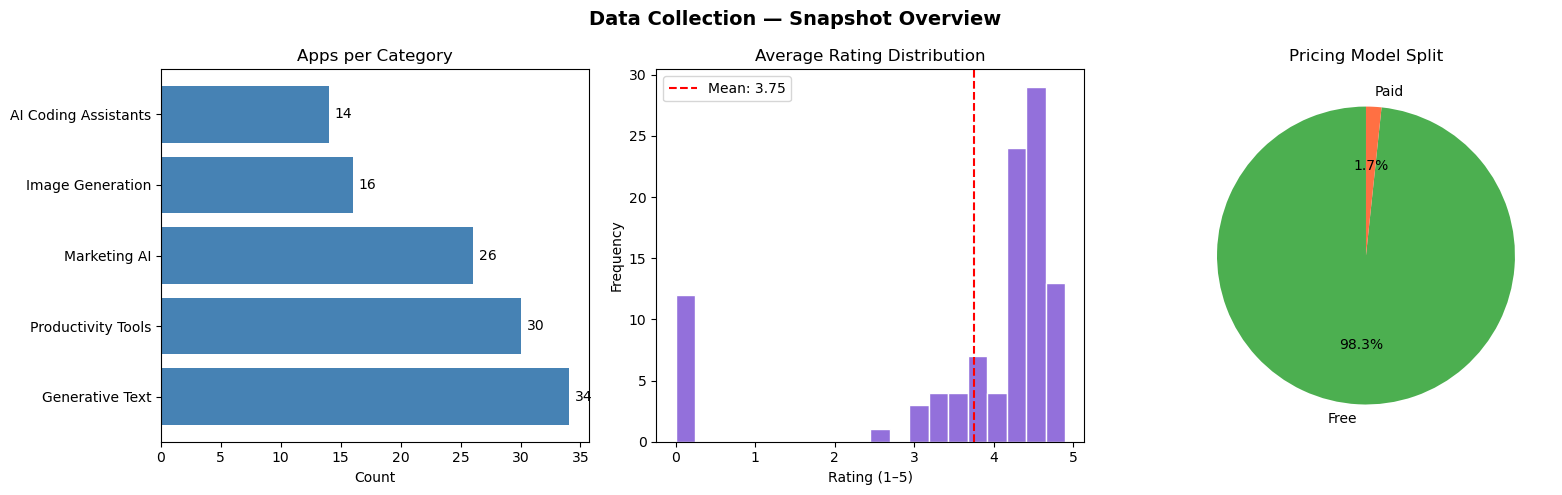

📊 Snapshot chart saved as: scraping_snapshot.png


In [10]:
# ── Quick EDA Snapshots ───────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Data Collection — Snapshot Overview', fontsize=14, fontweight='bold')

# Plot 1: Apps per category
cat_counts = metadata_df['project_category'].value_counts()
axes[0].barh(cat_counts.index, cat_counts.values, color='steelblue')
axes[0].set_title('Apps per Category')
axes[0].set_xlabel('Count')
for i, v in enumerate(cat_counts.values):
    axes[0].text(v + 0.5, i, str(v), va='center')

# Plot 2: avg_rating distribution
axes[1].hist(metadata_df['avg_rating'].dropna(), bins=20,
             color='mediumpurple', edgecolor='white')
axes[1].set_title('Average Rating Distribution')
axes[1].set_xlabel('Rating (1–5)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(metadata_df['avg_rating'].mean(), color='red',
                linestyle='--', label=f"Mean: {metadata_df['avg_rating'].mean():.2f}")
axes[1].legend()

# Plot 3: Pricing model
pricing = metadata_df['pricing_model'].value_counts()
axes[2].pie(pricing.values, labels=pricing.index,
            autopct='%1.1f%%', colors=['#4CAF50', '#FF7043'],
            startangle=90)
axes[2].set_title('Pricing Model Split')

plt.tight_layout()
plt.savefig('scraping_snapshot.png', dpi=150, bbox_inches='tight')
plt.show()
print("📊 Snapshot chart saved as: scraping_snapshot.png")

In [11]:
# ── Top 10 apps by total ratings (most established tools) ────────────────────

print("🏆 Top 10 AI Tools by Total Ratings:\n")
top10 = (
    metadata_df[['app_name', 'project_category', 'avg_rating', 'total_ratings', 'pricing_model']]
    .sort_values('total_ratings', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
top10.index = top10.index + 1  # Start ranking at 1
print(top10.to_string())

print("\n💎 Potential 'Hidden Gems' — High avg rating, Low total ratings:\n")
# Hidden gems: high quality but under-discovered
# This is a key concept in the project — Senti-Recommend will surface these
gems = (
    metadata_df[
        (metadata_df['avg_rating'] >= 4.5) &
        (metadata_df['total_ratings'] < metadata_df['total_ratings'].quantile(0.25))
    ][['app_name', 'project_category', 'avg_rating', 'total_ratings']]
    .sort_values('avg_rating', ascending=False)
    .head(10)
    .reset_index(drop=True)
)
gems.index = gems.index + 1
print(gems.to_string())

🏆 Top 10 AI Tools by Total Ratings:

                          app_name    project_category  avg_rating  total_ratings pricing_model
1                          ChatGPT     Generative Text    4.811088     40084180.0          Free
2                    Google Gemini     Generative Text    4.612127     29025397.0          Free
3            Microsoft 365 Copilot  Productivity Tools    4.565430      8749375.0          Free
4       Grok • Smartest AI Advisor     Generative Text    4.746201      2463481.0          Free
5              ​​Microsoft Copilot     Generative Text    4.694242      2178141.0          Free
6                AI Chatbot - Nova     Generative Text    3.816745      2108906.0          Free
7   Character AI: Chat, Talk, Text     Generative Text    3.352705      2072754.0          Free
8        Perplexity - Ask Anything     Generative Text    4.642536      1813627.0          Free
9      Chat AI: Ask Agent Anything     Generative Text    4.446276      1100174.0          Free
10 

---
## 📝 Section 9 — Session Summary & Pipeline Handoff

This section auto-generates a summary that can be copied directly into your project report.


In [12]:
# ── Auto-generate a session report ───────────────────────────────────────────

print("=" * 65)
print("  SENTI-RECOMMEND — DATA COLLECTION SESSION REPORT")
print("=" * 65)
print(f"  Generated  : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("")
print(f"  Source     : Google Play Store (via google-play-scraper)")
print(f"  Language   : English (en-US)")
print(f"  Categories : {len(CATEGORY_QUERIES)}")
print(f"  Search queries run : {sum(len(v) for v in CATEGORY_QUERIES.values())}")
print("")
print("  OUTPUT FILES:")
print(f"  ├── ai_tools_metadata.csv")
print(f"  │     Rows    : {len(metadata_df):,}")
print(f"  │     Columns : {metadata_df.shape[1]}")
print(f"  │     Avg rating (mean) : {metadata_df['avg_rating'].mean():.2f}")
print(f"  │     Free apps : {(metadata_df['pricing_model']=='Free').sum()}")
print(f"  │     Paid apps : {(metadata_df['pricing_model']=='Paid').sum()}")
print(f"  │")
print(f"  └── ai_tools_reviews.csv")
print(f"        Rows    : {len(reviews_export):,}")
print(f"        Columns : {reviews_export.shape[1]}")
print(f"        Avg review length : {reviews_df['review_length'].mean():.0f} chars")
print(f"        Developer reply rate : {reply_rate:.1f}%")
print("")
print("  NEXT STEP → 02_preprocessing.ipynb")
print("=" * 65)

  SENTI-RECOMMEND — DATA COLLECTION SESSION REPORT
  Generated  : 2026-02-25 21:16:20

  Source     : Google Play Store (via google-play-scraper)
  Language   : English (en-US)
  Categories : 5
  Search queries run : 17

  OUTPUT FILES:
  ├── ai_tools_metadata.csv
  │     Rows    : 120
  │     Columns : 30
  │     Avg rating (mean) : 3.75
  │     Free apps : 118
  │     Paid apps : 2
  │
  └── ai_tools_reviews.csv
        Rows    : 5,931
        Columns : 12
        Avg review length : 104 chars
        Developer reply rate : 29.5%

  NEXT STEP → 02_preprocessing.ipynb


---
## ⚠️ Section 10 — Limitations & Mitigations

Acknowledging limitations is an important part of academic reporting.

| Limitation | Impact | Mitigation Applied |
|---|---|---|
| Google Play only (Android bias) | May underrepresent web-only AI tools | Scope clearly defined; future work can add G2/Capterra |
| English-only reviews | Non-English user sentiment not captured | Scope defined as `lang='en'`; noted as a boundary |
| `REVIEWS_PER_APP` cap | Very active apps have many more reviews | Cap applied equally across all apps (fairness) |
| `NotFoundError` for some apps | Minor data loss | Logged to `scraping_errors.log`; does not crash pipeline |
| Dynamic content (JS-rendered pages) | BeautifulSoup cannot parse JS-rendered text | `google-play-scraper` bypasses this; noted for supplementary sources |
| Cold-start apps (zero reviews) | Cannot do sentiment analysis | Knowledge-Based fallback planned in hybrid engine (see project scope) |

---

## 🔗 What Comes Next?

This notebook produces two clean CSV files that feed the following pipeline stages:

```
01_scraping.ipynb  ← YOU ARE HERE
        ↓
02_preprocessing.ipynb   (text cleaning, normalisation, missing value handling)
        ↓
03_sentiment_analysis.ipynb  (VADER & Transformers, Aspect-Based Sentiment)
        ↓
04_collaborative_filtering.ipynb  (SVD via Surprise library)
        ↓
05_hybrid_fusion.ipynb   (weighted scoring, hidden gem detection)
        ↓
06_streamlit_app.py      (Senti-Recommend web dashboard)
```
